# Lab: Classification: Predicting Left-Handedness from Psychological Factors

---

One way to define the data science process is as follows:

1. Obtain the data.
2. Explore the data.
3. Model the data.
4. Evaluate the model.
5. Explain.

We'll walk through a full data science problem in this lab. 

---

You're currently a data scientist working at a university. A professor of psychology is attempting to study the relationship between personalities and left-handedness. They have tasked you with gathering evidence so that they may publish.

> You might find it helpful to check out the codebook in the repo for some inspiration.

---
## Importing Libraries

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and Pipeline creation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

## Obtain the data.

### Read in the file titled "data.csv":
> Hint: Despite being saved as a .csv file, you won't be able to simply `pd.read_csv()` this data!

In [2]:
# Load and view a smaple of the data
df = pd.read_csv('data.csv')

In [3]:
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,testelapse,country,fromgoogle,engnat,age,education,gender,race,religion,hand
0,4,1,5,1,5,1,5,1,4,1,...,232,US,2,1,22,3,1,3,2,3
1,1,5,1,4,2,5,5,4,1,5,...,247,CA,2,1,14,1,2,6,1,1
2,1,2,1,1,5,4,3,2,1,4,...,6774,NL,2,2,30,4,1,1,1,2
3,1,4,1,5,1,4,5,4,3,5,...,1072,US,2,1,18,2,2,3,2,2
4,5,1,5,1,5,1,5,1,3,1,...,226,US,2,1,22,3,1,3,2,3


---

## Explore the data.

### Conduct background research:

Domain knowledge is irreplaceable. Figuring out what information is relevant to a problem, or what data would be useful to gather, is a major part of any end-to-end data science project! For this lab, you'll be using a dataset that someone else has put together, rather than collecting the data yourself.

Do some background research about personality and handedness. What features, if any, are likely to help you make good predictions? How well do you think you'll be able to model this? Write a few bullet points summarizing what you believe, and remember to cite external sources.

You don't have to be exhaustive here. Do enough research to form an opinion, and then move on.

> You'll be using the answers to Q1-Q44 for modeling; you can disregard other features, e.g. country, age, internet browser.

### Research Finding [1] – Visual-Spatial Perception and Memory

> "Left-handed children most often have impaired reading and writing, impairments or deficiencies in the development of visual-spatial perception, visual memory, and impaired visual-motor coordination." [1]

**Features identified:**
- Reading and writing
- Visual-spatial perception
- Visual memory
- Visual-motor coordination

**Related Questions:**
- **Q6:** "I get embarrassed when people read things I have written."
- **Q11:** "I did not work very hard in school."
- **Q13:** "I would prefer a class in mathematics to a class in pottery."


### Research Finding [2] – Creativity and Non-Standard Thinking

> "Left-handers show, on the one hand, great creative abilities (unsettled connections can theoretically contribute to non-standard thinking)." [1]

**Features identified:**
- Creativity
- Non-standard thinking
- Creative expression

**Related Questions:**
- **Q2:** "I have thought about dying my hair."
- **Q4:** "I give people handmade gifts."
- **Q34:** "I have kept a personal journal."
- **Q44:** "I decorate my things (e.g. stickers on laptop)."


### Research Finding [3] – Emotionality, Imagination and Intuition

> "Left-handed children are emotional, dreamy, with vivid fantasies and imagination, rely on intuition, follow feeling more than reason." [1]

**Features identified:**
- Emotionality
- Dreaminess
- Imagination
- Intuition
- Feeling-oriented behavior

**Related Questions:**
- **Q5:** "I have daydreamed about saving someone from a burning building."
- **Q14:** "I dance when I am alone."
- **Q16:** "When I was a child, I put on fake concerts and plays with my friends."
- **Q20:** "I sometimes feel like crying when I get angry."
- **Q26:** "I jump up and down in excitement sometimes."
- **Q30:** "I think horoscopes are fun."
- **Q34:** "I have kept a personal journal."
- **Q40:** "I really like dancing."


### Research Finding [4] – Timidity and Emotional Sensitivity

> "Left-handed children are more timid, behave calmly, wait to be addressed, they themselves do not enter the conversation first. They are very impressionable, emotionally sensitive, vulnerable, touchy." [1]

**Features identified:**
- Timidity
- Emotional sensitivity
- Vulnerability
- Reserved social behavior

**Related Questions:**
- **Q6:** "I get embarrassed when people read things I have written."
- **Q10:** "I am happiest when I am in my bed."
- **Q19:** "I do not think it is normal to get emotionally upset upon hearing about the deaths of people you did not know."
- **Q20:** "I sometimes feel like crying when I get angry."
- **Q22:** "I save the letters I get."
- **Q38:** "I leave nice notes for people now and then."



### Research Finding [5] – Impulsivity and Spontaneous Behavior

> "They are impatient, intemperate, there is a reduced level of subjective control. In life, this is manifested as follows: a left-hander starts up with a half-turn, easily falls into a rage. The activity is spontaneous, relying on a lucky break." [1]

**Features identified:**
- Impulsivity
- Impatience
- Spontaneity
- Emotional reactivity
- Risk-taking behavior

**Related Questions:**
- **Q3:** "I have thrown knives, axes or other sharp things."
- **Q15:** "I have thought it would be exciting to be an outlaw."
- **Q20:** "I sometimes feel like crying when I get angry."
- **Q23:** "I playfully insult my friends."
- **Q41:** "I take stairs two at a time."


### Research Finding [6] – Independent Work, Initiative and Creativity

> "They prefer individual work where they can show their own initiative and intuition, creativity and imagination." [1]

**Features identified:**
- Independence
- Initiative
- Intuition
- Creativity
- Imagination

**Related Questions:**
- **Q1:** "I have studied how to win at card games."
- **Q42:** "I bake sweets just for myself sometimes."


### Research Finding [7] – Analytical Thinking and Attention to Detail

> "Lefties use a special information processing strategy, an analytical style of cognition... They are characterized by detailed component-wise work or work with details." [1]

**Features identified:**
- Analytical thinking
- Attention to detail
- Information processing
- Problem-solving

**Related Questions:**
- **Q1:** "I have studied how to win at card games."
- **Q35:** "I have taken apart machines just to see how they work."


## Candidate Questions Based on Background Research

Based on the psychological characteristics identified in the research, the following questions may be useful candidates for predicting handedness:

**Q1, Q2, Q3, Q4, Q5, Q6, Q10, Q11, Q13, Q14, Q15, Q16, Q19, Q20, Q22, Q23, Q26, Q30, Q34, Q35, Q38, Q40, Q41, Q42, Q44**

These questions are selected as potential features based on their conceptual relationship with characteristics of left-handed people discussed in the research. Their actual predictive importance should later be evaluated using EDA, statistical analysis, and machine-learning feature importance.


## Reference

[1] Qo‘ldoshev, R. A. (2021). "Psychological Aspects of Left-Handedness: Concept, Causes, and Peculiarities." *Psychology and Education*, 58(1), 4981–4988.

In [4]:
# Filter your data to include Q1 to Q44 and hand
# Filter data to include candidate questions from background research and hand

candidate_questions = [
    'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6',
    'Q10', 'Q11', 'Q13', 'Q14', 'Q15', 'Q16',
    'Q19', 'Q20', 'Q22', 'Q23', 'Q26', 'Q30',
    'Q34', 'Q35', 'Q38', 'Q40', 'Q41', 'Q42', 'Q44'
]

# Add the target column
selected_columns = candidate_questions + ['hand']

# Filter the dataframe
df_filtered = df[selected_columns]

# Check the result
df_filtered.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q10,Q11,Q13,Q14,...,Q26,Q30,Q34,Q35,Q38,Q40,Q41,Q42,Q44,hand
0,4,1,5,1,5,1,1,1,5,5,...,5,1,5,5,1,5,5,1,1,3
1,1,5,1,4,2,5,5,2,3,4,...,2,3,4,4,4,3,1,4,5,1
2,1,2,1,1,5,4,4,4,4,3,...,2,4,4,2,2,4,2,2,2,2
3,1,4,1,5,1,4,5,1,2,3,...,4,3,5,5,4,2,1,1,3,2
4,5,1,5,1,5,1,1,1,5,5,...,5,1,5,5,1,5,5,1,1,3


### Conduct exploratory data analysis on this dataset:

If you haven't already, be sure to check out the codebook in the repo, as that will help in your EDA process.

You might use this section to perform data cleaning if you find it to be necessary.

In [5]:
# Check Data Information
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 4184 entries, 0 to 4183
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Q1      4184 non-null   int64
 1   Q2      4184 non-null   int64
 2   Q3      4184 non-null   int64
 3   Q4      4184 non-null   int64
 4   Q5      4184 non-null   int64
 5   Q6      4184 non-null   int64
 6   Q10     4184 non-null   int64
 7   Q11     4184 non-null   int64
 8   Q13     4184 non-null   int64
 9   Q14     4184 non-null   int64
 10  Q15     4184 non-null   int64
 11  Q16     4184 non-null   int64
 12  Q19     4184 non-null   int64
 13  Q20     4184 non-null   int64
 14  Q22     4184 non-null   int64
 15  Q23     4184 non-null   int64
 16  Q26     4184 non-null   int64
 17  Q30     4184 non-null   int64
 18  Q34     4184 non-null   int64
 19  Q35     4184 non-null   int64
 20  Q38     4184 non-null   int64
 21  Q40     4184 non-null   int64
 22  Q41     4184 non-null   int64
 23  Q42     4184 non-null   

In [6]:
# Summary Stat.
df_filtered.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q10,Q11,Q13,Q14,...,Q26,Q30,Q34,Q35,Q38,Q40,Q41,Q42,Q44,hand
count,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,...,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000,4184.000000
mean,1.962715,3.829589,2.846558,3.186902,2.865440,3.672084,3.522945,2.748805,2.657505,3.334130,...,3.001434,2.894359,3.022228,3.074092,2.798757,2.984226,3.385277,2.704828,2.736616,1.190966
std,1.360291,1.551683,1.664804,1.476879,1.545798,1.342238,1.242890,1.443078,1.559575,1.522866,...,1.480610,1.477968,1.562694,1.546400,1.413584,1.483752,1.423055,1.544345,1.471845,0.495357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,1.000000,2.000000,1.000000,3.000000,3.000000,1.000000,1.000000,2.000000,...,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000
50%,1.000000,5.000000,3.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,1.000000
75%,3.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,5.000000,...,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000


In [7]:
# Check for nulls
df_filtered.isnull().sum()

Q1      0
Q2      0
Q3      0
Q4      0
Q5      0
Q6      0
Q10     0
Q11     0
Q13     0
Q14     0
Q15     0
Q16     0
Q19     0
Q20     0
Q22     0
Q23     0
Q26     0
Q30     0
Q34     0
Q35     0
Q38     0
Q40     0
Q41     0
Q42     0
Q44     0
hand    0
dtype: int64

__Quick Question: What type of values do features Q1 to Q44 contain? (NOT datatype)__

> Enter your answer here
> The Q1–Q44 features contain **ordinal values** representing responses on a
5-point Likert scale:
> - **1 = Disagree**
> - **2 = Slightly Disagree**
> - **3 = Neutral**
> - **4 = Slightly Agree**
> - **5 = Agree**

The values are ordinal because they have a meaningful order from disagreement
to agreement.


__[Use Spearman Correlation](https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/)__

Spearman correlation refers to a nonparametric statistical technique used to assess the strength and direction of the relationship between the ranks of two ordinal variables, which can be either quantitative or qualitative. It ranges from −1 to +1, with values indicating perfect negative or positive relationships, respectively, and a value of 0 signifying no relationship, while being less affected by outliers. _**- ScienceDirect**_

In [8]:
df_filtered = df_filtered[df_filtered['hand'] != 0]

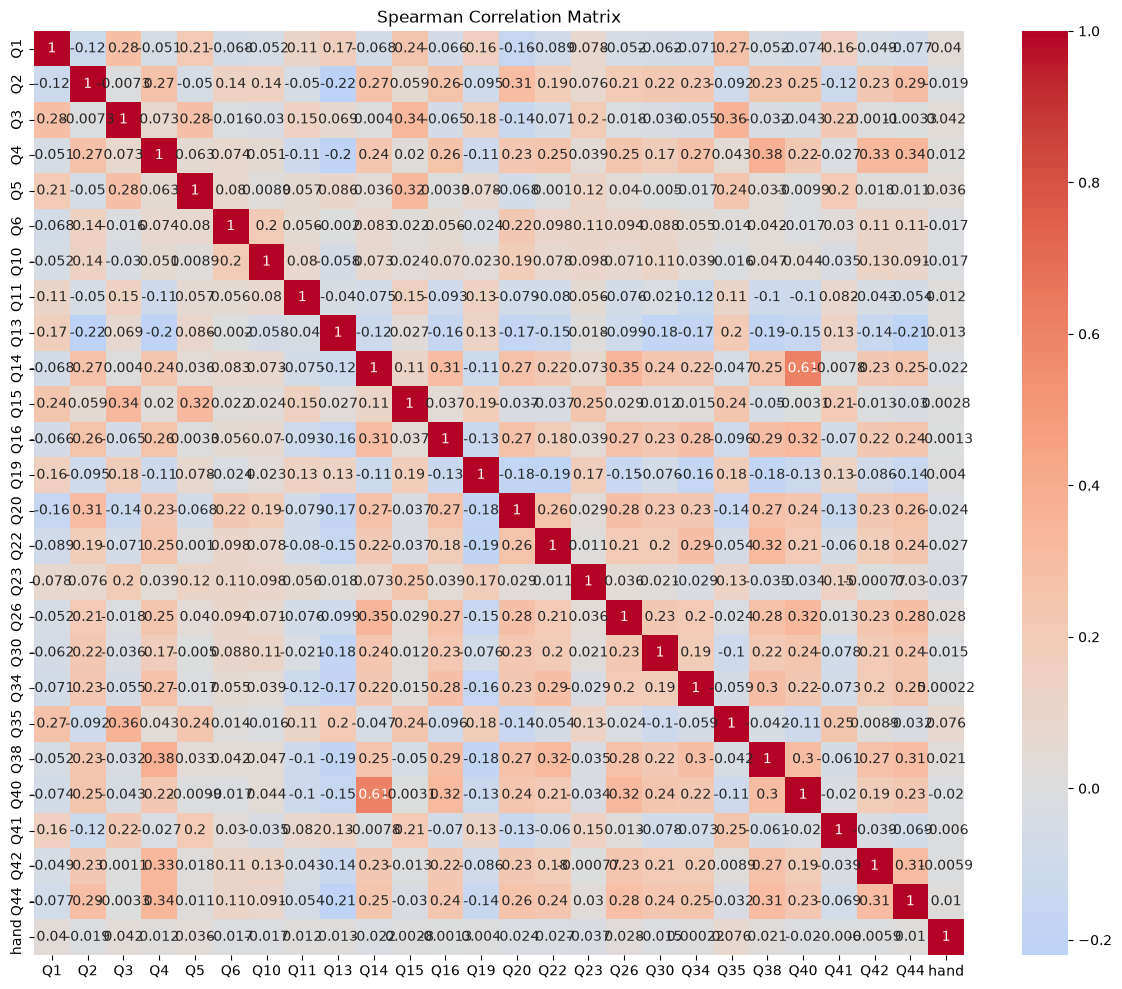

In [9]:
# Check correlation using 'spearman'
corr = df_filtered.corr(method='spearman')

plt.figure(figsize=(15, 12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True
)

plt.title('Spearman Correlation Matrix')
plt.show()

In [10]:
pd.set_option('display.max_columns', None)
corr

,Q1,Q2,Q3,Q4,Q5,Q6,Q10,Q11,Q13,Q14,Q15,Q16,Q19,Q20,Q22,Q23,Q26,Q30,Q34,Q35,Q38,Q40,Q41,Q42,Q44,hand
Q1,1.000000,-0.118293,0.281179,-0.051291,0.210200,-0.068366,-0.051953,0.110602,0.169943,-0.068238,0.243272,-0.066187,0.161562,-0.160154,-0.089333,0.077712,-0.052177,-0.062339,-0.070551,0.267691,-0.052472,-0.074095,0.161980,-0.048638,-0.077328,0.040034
Q2,-0.118293,1.000000,-0.007296,0.266734,-0.050459,0.143317,0.141940,-0.050321,-0.219980,0.274857,0.058915,0.261205,-0.094960,0.313393,0.186746,0.076137,0.208616,0.218879,0.228768,-0.092070,0.233525,0.245282,-0.122455,0.226497,0.291046,-0.019135
Q3,0.281179,-0.007296,1.000000,0.072577,0.278761,-0.015521,-0.030263,0.148943,0.068940,0.004044,0.337972,-0.064929,0.179786,-0.137505,-0.070803,0.196857,-0.018115,-0.036122,-0.055017,0.364195,-0.031966,-0.042547,0.217471,0.001089,-0.003280,0.041925
Q4,-0.051291,0.266734,0.072577,1.000000,0.062875,0.074129,0.051124,-0.105603,-0.203434,0.239012,0.020422,0.257202,-0.105371,0.228285,0.254408,0.039205,0.251712,0.172921,0.271080,0.042817,0.376607,0.221503,-0.026520,0.330242,0.340332,0.012462
Q5,0.210200,-0.050459,0.278761,0.062875,1.000000,0.080170,0.008920,0.056720,0.086438,0.035678,0.323850,0.003255,0.078134,-0.068043,0.000998,0.119465,0.040245,-0.004993,-0.016918,0.239109,0.032802,-0.009929,0.204437,0.017682,0.011211,0.036035
Q6,-0.068366,0.143317,-0.015521,0.074129,0.080170,1.000000,0.196369,0.055674,-0.002032,0.083064,0.021909,0.056229,-0.023957,0.223683,0.097698,0.114675,0.093848,0.087926,0.055152,0.013661,0.042335,-0.016608,0.030270,0.114998,0.109558,-0.016644
Q10,-0.051953,0.141940,-0.030263,0.051124,0.008920,0.196369,1.000000,0.080390,-0.057665,0.072620,0.023772,0.070327,0.023221,0.189837,0.077788,0.097517,0.070575,0.111078,0.038973,-0.016257,0.046796,0.044442,-0.034609,0.127108,0.091218,-0.017406
Q11,0.110602,-0.050321,0.148943,-0.105603,0.056720,0.055674,0.080390,1.000000,-0.040319,-0.074656,0.154665,-0.092530,0.133443,-0.079121,-0.079631,0.056024,-0.076451,-0.021368,-0.120462,0.110842,-0.101943,-0.104789,0.081521,-0.042879,-0.053848,0.011654
Q13,0.169943,-0.219980,0.068940,-0.203434,0.086438,-0.002032,-0.057665,-0.040319,1.000000,-0.120286,0.027136,-0.155035,0.131600,-0.169669,-0.150339,0.018127,-0.098636,-0.184460,-0.169616,0.204506,-0.189494,-0.154951,0.128457,-0.136382,-0.206293,0.013180
Q14,-0.068238,0.274857,0.004044,0.239012,0.035678,0.083064,0.072620,-0.074656,-0.120286,1.000000,0.111158,0.308197,-0.113524,0.266132,0.217637,0.072751,0.348220,0.239623,0.219237,-0.047183,0.253608,0.609726,-0.007837,0.227434,0.250691,-0.022385


__Inspect the Target__

**Quick Question:** What does each number in the target column represent?
> Enter your answer
> The `hand` column represents the participant's handedness:

> - **1 = Right-handed**
> - **2 = Left-handed**
> - **3 = Both hands (ambidextrous)**
> - The value **0 is not defined as a valid category in the codebook, so those records were removed before modeling.**

In [11]:
# Target Distribution, What do the numbers represents? hmmm...something is off. What do you notice?
df_filtered['hand'].value_counts().sort_index()

hand
1    3542
2     452
3     179
Name: count, dtype: int64

In [12]:
df_filtered['hand'].value_counts(normalize=True).sort_index()

hand
1    0.848790
2    0.108315
3    0.042895
Name: proportion, dtype: float64

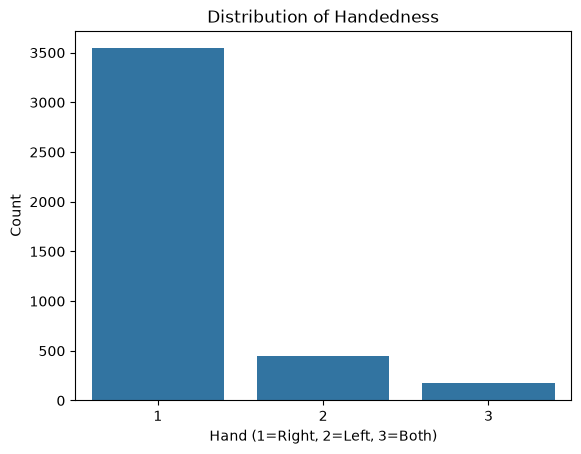

In [13]:
sns.countplot(data=df_filtered, x='hand')
plt.title('Distribution of Handedness')
plt.xlabel('Hand (1=Right, 2=Left, 3=Both)')
plt.ylabel('Count')
plt.show()


In [14]:
# What needs to be removed from the Target? 0
df_filtered = df_filtered[df_filtered['hand'].isin([1, 2])]


In [15]:
# Keep only right-handed and left-handed participants
df_filtered = df_filtered[df_filtered['hand'].isin([1, 2])]

In [16]:
df_filtered['hand'].value_counts()

hand
1    3542
2     452
Name: count, dtype: int64

In [17]:
# Convert target to binary:
# 0 = Right-handed
# 1 = Left-handed
df_filtered['hand'] = df_filtered['hand'].map({
    1: 0,
    2: 1
})

# Check distribution
df_filtered['hand'].value_counts()

hand
0    3542
1     452
Name: count, dtype: int64

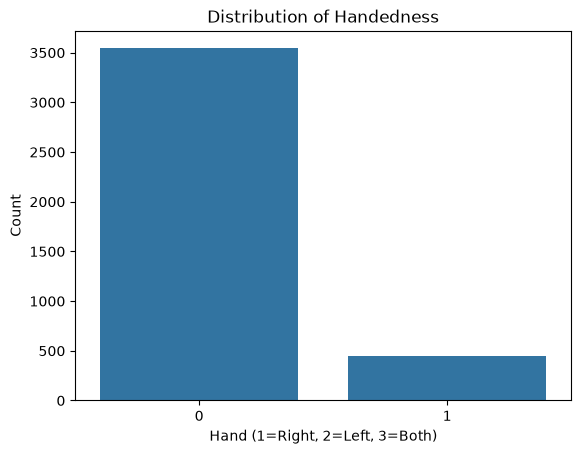

In [18]:
sns.countplot(data=df_filtered, x='hand')
plt.title('Distribution of Handedness')
plt.xlabel('Hand (1=Right, 2=Left, 3=Both)')
plt.ylabel('Count')
plt.show()


In [19]:
# We can tackle the following either by:
# 1. Strictly focusing on Left handed only
# 2. We can consider both handed as left handed since they use their left hand
# What will you choose?


## Let's see which performs the best: SVM vs. Random Forest vs. XGBoost
1. Tryout building a base model for each.
2. Improve each model using Grid Search and Pipelines.

### Data Splitting

In [20]:
# Identify your X and y
X = df_filtered.drop(columns='hand')
y = df_filtered['hand']



In [21]:
# Split the data to train and test for each X and y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Building the Base Model
__Note:__ Using Pipeline ensures that the StandardScaler is applied properly—fitting only on the training data to prevent data leakage, and then transforming both the training and testing data.

In [22]:
# SVM Base Model
svm_base = Pipeline([
    ('model', SVC(random_state=42))
])
svm_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['Q1','Q2','Q3',...,'Q41','Q42','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'


In [23]:
# Random Forest Base Model
rf_base = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

rf_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['Q1','Q2','Q3',...,'Q41','Q42','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [24]:
# XGBoost Base Model
xgboost_base = Pipeline([
    ('model', XGBClassifier(random_state=42))
])

xgboost_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[<U3](25,)","['Q1','Q2','Q3',...,'Q41','Q42','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


__Checking the Base Models performance__

In [25]:
# SVM Base Model Result

# Predictions
y_pred_svm = svm_base.predict(X_test)

# Results
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       709
           1       0.00      0.00      0.00        90

    accuracy                           0.89       799
   macro avg       0.44      0.50      0.47       799
weighted avg       0.79      0.89      0.83       799

Confusion Matrix:
[[709   0]
 [ 90   0]]


C:\Users\elias\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elias\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elias\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
pd.Series(y_pred_svm).value_counts()

0    799
Name: count, dtype: int64

In [27]:
# Random Forest Base Model Result
# Predictions
y_pred_rf = rf_base.predict(X_test)

# Results
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       709
           1       0.00      0.00      0.00        90

    accuracy                           0.89       799
   macro avg       0.44      0.50      0.47       799
weighted avg       0.79      0.89      0.83       799

Confusion Matrix:
[[709   0]
 [ 90   0]]


C:\Users\elias\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elias\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elias\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [28]:
# XGBoost Model Result
# Predictions
y_pred_xgb = xgboost_base.predict(X_test)

# Results
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       709
           1       0.25      0.02      0.04        90

    accuracy                           0.88       799
   macro avg       0.57      0.51      0.49       799
weighted avg       0.82      0.88      0.84       799

Confusion Matrix:
[[703   6]
 [ 88   2]]


__Comparing the base model performance__

In [29]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model_performance(model, X_test, y_test, target_names):
    """
    Generates predictions, displays the classification report and confusion matrix.
    """

    # Generate predictions
    y_pred = model.predict(X_test)

    # Display the Classification Report
    print("=====================================================")
    print("              CLASSIFICATION REPORT")
    print("=====================================================")

    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

    # Display Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, cmap='Blues')

    plt.title("Confusion Matrix")
    plt.show()

In [30]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=34)
# ss = StandardScaler()

# X_train_ss = ss.fit_transform(X_train)
# X_test_ss = ss.transform(X_test)
# X_train_smote, y_train_smote = smote.fit_resample(X_train_ss, y_train)

# y_train_smote.value_counts()

hand
0    2833
1    2833
Name: count, dtype: int64

__1. SVM Base Model Performance__

              CLASSIFICATION REPORT
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       709
Left-Handed (1)       0.00      0.00      0.00        90

       accuracy                           0.89       799
      macro avg       0.44      0.50      0.47       799
   weighted avg       0.79      0.89      0.83       799



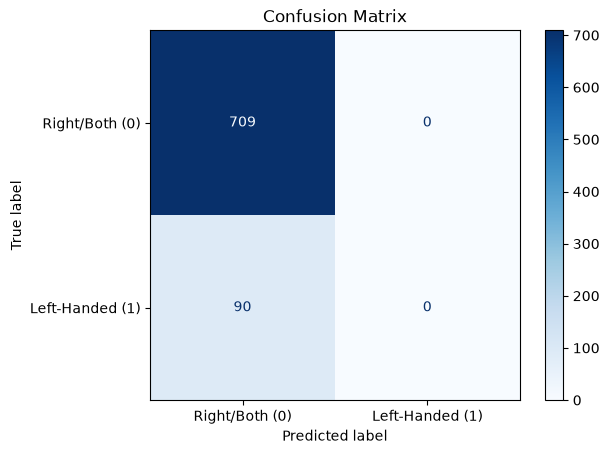

In [45]:
# SVM Base Model Performance
target_classes = ['Right/Both (0)', 'Left-Handed (1)']

svm = SVC(random_state=42)
svm.fit(X_train, y_train)

evaluate_model_performance(svm, X_test,y_test ,target_classes)

__2. Random Forest Base Model Performance__

              CLASSIFICATION REPORT
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      1.00      0.94       709
Left-Handed (1)       0.00      0.00      0.00        90

       accuracy                           0.89       799
      macro avg       0.44      0.50      0.47       799
   weighted avg       0.79      0.89      0.83       799



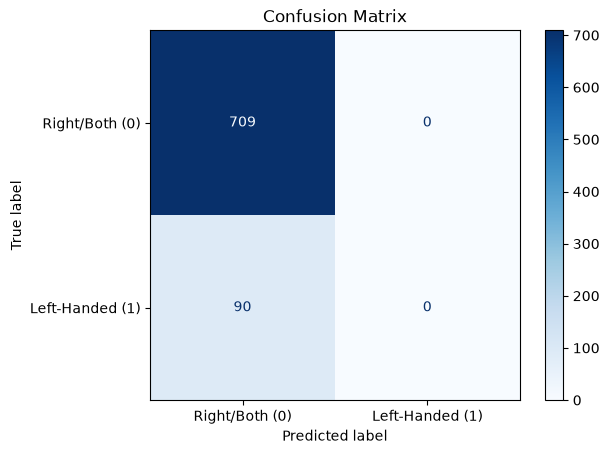

In [46]:
# Random Forest Base Model Performance
X_train_smote = pd.DataFrame(
    X_train_smote,
    columns=X_train.columns
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

evaluate_model_performance(rf, X_test, y_test, target_classes)


__3. XGBoost Base Model Performance__

              CLASSIFICATION REPORT
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      0.99      0.94       709
Left-Handed (1)       0.25      0.02      0.04        90

       accuracy                           0.88       799
      macro avg       0.57      0.51      0.49       799
   weighted avg       0.82      0.88      0.84       799



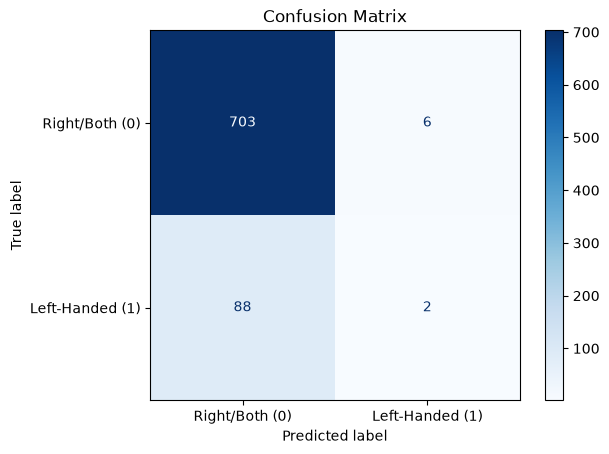

In [47]:
# XGBoost Base Model Performance
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

evaluate_model_performance(xgb, X_test, y_test,target_classes)

## Grid Search
Now that we've set up the base models and established why default accuracy can be misleading, let's move on to hyperparameter tuning with GridSearchCV.

__Key Concept:__ Parameter Naming in Pipelines

When tuning a model inside a Pipeline, GridSearchCV requires a specific syntax to know which step the hyperparameter belongs to:

>`step_name__parameter_name`

__*Note:*__ Always use a double underscore (__) between the pipeline step name (e.g., 'logreg') and the parameter name (e.g., 'C'). Writing logreg_C instead of logreg__C is one of the most common errors when tuning pipelines!

In [48]:
svm_pipeline = Pipeline([('svm', SVC(class_weight='balanced'))])
rf_pipeline = Pipeline([('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))])
xgboost_pipeline = Pipeline([('xgboost', XGBClassifier(random_state=42, class_weight='balanced'))])

In [49]:
# SVM Grid Search Parameters
svm_param_grid = {
    'svm__C': [10, 100],
    'svm__kernel': ['rbf'],
    'svm__gamma': ['scale', 0.1]
}

In [50]:
# Random Forest Grid Search Parameters
rf_param_grid = {
    'rf__n_estimators': [200, 300],
    'rf__max_depth': [None, 10],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt']
}

In [51]:
# XXGBoost Grid Search Parameters
xgboost_param_grid = {
    'xgboost__n_estimators': [200, 300],
    'xgboost__max_depth': [3, 5],
    'xgboost__learning_rate': [0.05, 0.1, 0.2],
    'xgboost__subsample': [0.8],
    'xgboost__colsample_bytree': [0.8]
}

__Setting up and fitting GridSearch__

Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV F1-Score: 0.10672864202361106
              CLASSIFICATION REPORT
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      0.91      0.90       709
Left-Handed (1)       0.15      0.13      0.14        90

       accuracy                           0.82       799
      macro avg       0.52      0.52      0.52       799
   weighted avg       0.81      0.82      0.81       799



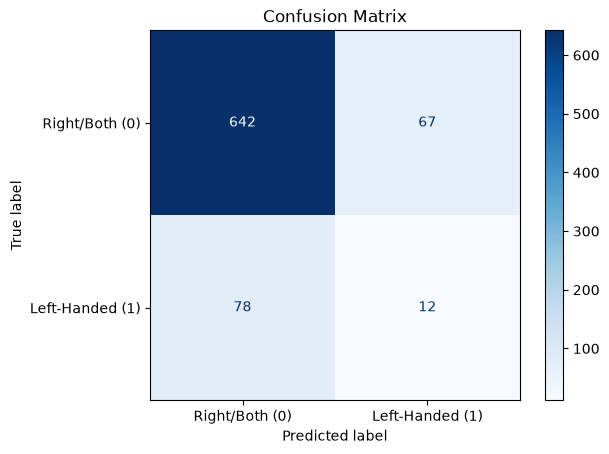

In [55]:
# Setting up and fitting GridSearch for SVM
grid_svm = GridSearchCV( svm_pipeline, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
grid_svm.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1-Score:", grid_svm.best_score_)

# Evaluate best estimator on test set
evaluate_model_performance(grid_svm.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best CV F1-Score: 0.06734001074202259
              CLASSIFICATION REPORT
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      0.98      0.93       709
Left-Handed (1)       0.27      0.07      0.11        90

       accuracy                           0.87       799
      macro avg       0.58      0.52      0.52       799
   weighted avg       0.82      0.87      0.84       799



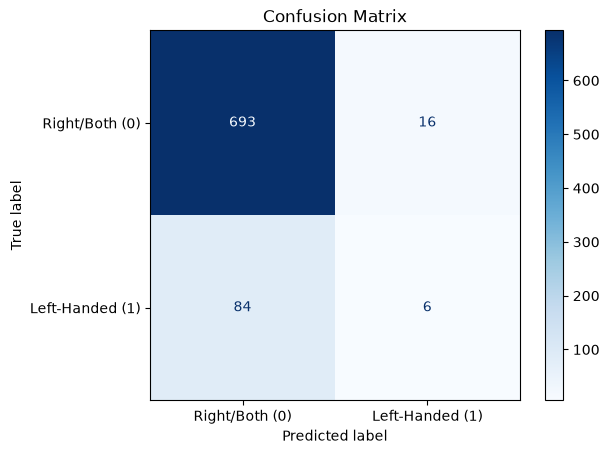

In [57]:
# Setting up and fitting GridSearch for Random Forest
grid_rf = GridSearchCV( rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
grid_rf.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1-Score:", grid_rf.best_score_)

# Evaluate best estimator on test set
evaluate_model_performance(grid_rf.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best CV F1-Score: 0.06734001074202259
              CLASSIFICATION REPORT
                 precision    recall  f1-score   support

 Right/Both (0)       0.89      0.98      0.93       709
Left-Handed (1)       0.27      0.07      0.11        90

       accuracy                           0.87       799
      macro avg       0.58      0.52      0.52       799
   weighted avg       0.82      0.87      0.84       799



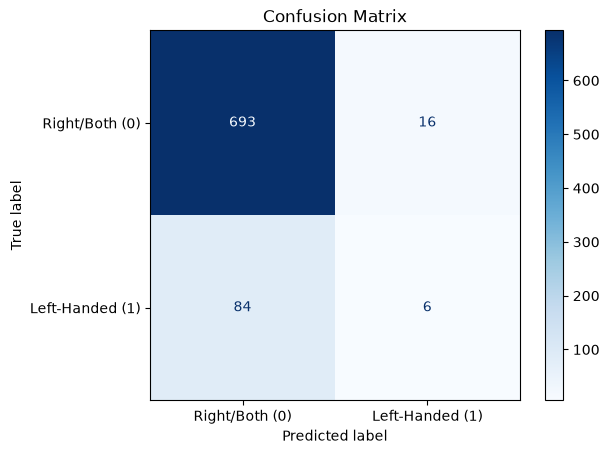

In [58]:
grid_rf = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit on training data
grid_rf.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1-Score:", grid_rf.best_score_)

# Evaluate best estimator on test set
evaluate_model_performance( grid_rf.best_estimator_, X_test, y_test, target_classes)

## Final Model Selection and Justification
Now that you have built, tuned, and evaluated all three models (SVM, Random Forest, and XGBoost), you must choose one model as your final production model.

Write a short justification to your selection. Your response must clearly address the following four points:

- __The Winning Model:__ Explicitly state which tuned model you are selecting.
- __Metric-Driven Justification:__ Defend your choice using the correct evaluation metrics. Explain why you relied on metrics like F1-Score or Recall for the minority class (Left-Handed) rather than overall Accuracy.
- __Model Comparison:__ Briefly explain why you rejected the other two models. (e.g., Did they struggle with recall? Were they computationally too expensive? Were they uninterpretable "black boxes"?)
- __Real-World Application:__ Explain how your chosen model serves the actual goal of this behavioral study. For example, if your model allows for feature extraction, how could psychologists use that information?

### Example Response Structure (Do not copy verbatim):
> __Final Model Selection: Tuned Logistic Regression__

>__*Justification:*__
I selected the Tuned Logistic Regression model because it provided the best balance of performance and interpretability for our imbalanced dataset. While the base models achieved a deceptively high accuracy of ~89%, the confusion matrices revealed they completely failed to identify left-handed individuals (Recall near 0%). By applying class_weight='balanced' during hyperparameter tuning, the Logistic Regression model successfully penalized minority class misclassifications, leading to the highest F1-Score for the left-handed class compared to the other algorithms.

>I rejected KNN because it struggled with the high dimensionality of the 44 survey questions, resulting in the weakest minority class recall even after tuning. While SVM achieved a similar F1-Score to Logistic Regression, I ultimately rejected it because the RBF kernel acts as a "black box."

>In the context of a psychological behavioral study, interpretability is just as important as predictive power. Logistic Regression allows us to extract the feature coefficients, meaning researchers can actually see which specific behaviors strongly correlate with being left-handed or right-handed, rather than just receiving a blind prediction.

#### Enter your Answer here

>**Winning Model:** I selected the **Tuned SVM with the RBF kernel** as the final model. The best parameters were `C = 10`, `gamma = 'scale'`, and `kernel = 'rbf'`.

>**Metric-Driven Justification:** Since the dataset is highly imbalanced, overall accuracy is not the most appropriate metric for selecting the model. The main objective is to correctly identify **left-handed individuals (class 1)**, so I focused primarily on the **F1-score and recall of the left-handed class**. The tuned SVM achieved a left-handed **F1-score of 0.14**, **recall of 0.13**, and **precision of 0.15**. It correctly identified **12 out of 90 left-handed individuals** in the test set. Although its overall accuracy was only **82%**, it was more successful at detecting the minority class than the other tested models.

>**Model Comparison:** Random Forest achieved a higher overall accuracy of **87%**, but this result is misleading because it mainly performed well on the majority right-handed class. It achieved only **0.07 recall** and **0.11 F1-score** for left-handed individuals, correctly identifying only **6 out of 90** left-handed participants. Therefore, SVM was preferred because it provided better minority-class detection. The other model was also not selected because it did not provide a better balance of minority-class recall and F1-score than the tuned SVM.

>**Real-World Application:** In this behavioral study, the goal is not simply to achieve high overall accuracy but to identify behavioral patterns that may help distinguish left-handed individuals. The tuned SVM provides the strongest minority-class performance among the tested models. However, its left-handed recall of **13% is still low**, meaning that the model misses most left-handed participants. Therefore, this model should be considered the **best of the models tested rather than a production-ready predictor**. Further improvements, such as addressing class imbalance, collecting more left-handed observations, and improving feature selection, would be necessary before using the model in a real-world psychological application.



### The Demographic Impact (Bonus/Extension)

Up until now, we have exclusively used the 44 behavioral questions (Q1–Q44) to predict handedness. We intentionally ignored the demographic data of the survey participants.

For this final challenge, your task is to see if incorporating demographic information improves your best model's predictive power. __Are behavioral questions enough to predict whether someone is left-handed, or does demographic information significantly influence the outcome?__

__EDA & Data Cleaning__

In [41]:
# Enter you process....


__Preprocessing__

In [42]:
# Enter you process....


__Modeling__

In [43]:
# Enter you process....


__Evaluating the Model__

In [44]:
# Enter you process....


#### What was the difference in performance?  

>Enter your answer here!